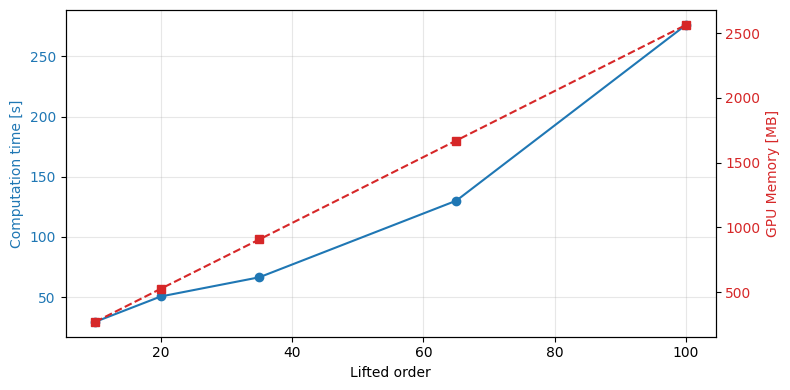

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

sweep_dir = Path("Figures/lifted_order_sweep_20260618_042150")

rows = []
for path in sorted(sweep_dir.glob("lifted_order_*.json")):
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    gpu_mem = payload.get("gpu_memory")
    if isinstance(gpu_mem, list):
        gpu_mem_mb = max(gpu_mem) if gpu_mem else None
    elif isinstance(gpu_mem, dict):
        gpu_mem_mb = gpu_mem.get("peak_allocated_mb") or gpu_mem.get("peak_reserved_mb")
    else:
        gpu_mem_mb = gpu_mem

    rows.append({
        "lifting_order": payload["lifting_order"],
        "time_s": payload["computation_time_seconds"],
        "gpu_memory_mb": gpu_mem_mb,
        "json_file": path.name,
    })

df_lift = pd.DataFrame(rows).sort_values("lifting_order")
df_lift["total_iterations"] = df_lift["json_file"].apply(
    lambda name: json.loads((sweep_dir / name).read_text(encoding="utf-8"))["total_iters"]
)

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(df_lift["lifting_order"], df_lift["time_s"], "o-", color="tab:blue")
ax1.set_xlabel("Lifted order")
ax1.set_ylabel("Computation time [s]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_lift["lifting_order"], df_lift["gpu_memory_mb"], "s--", color="tab:red")
ax2.set_ylabel("GPU Memory [MB]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# fig.suptitle("Lifted-order sweep: compute cost")
fig.tight_layout()
plt.show()

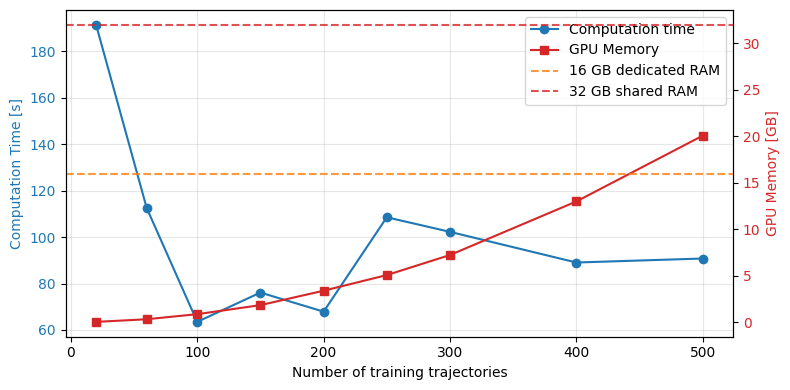

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

sweep_dir = Path(r"Figures\numtraj_sweep_20260618_044605")

rows = []
for path in sorted(sweep_dir.glob("numtrain_*.json")):
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    gpu_mem = payload.get("gpu_memory")
    if isinstance(gpu_mem, list):
        gpu_mem_mb = max(gpu_mem) if gpu_mem else None
    elif isinstance(gpu_mem, dict):
        gpu_mem_mb = (
            gpu_mem.get("peak_allocated_mb")
            or gpu_mem.get("peak_reserved_mb")
            or gpu_mem.get("final_allocated_mb")
            or gpu_mem.get("final_reserved_mb")
        )
    else:
        gpu_mem_mb = gpu_mem

    rows.append({
        "num_train": payload["num_train_trajectories"],
        "time_s": payload["computation_time_seconds"],
        "gpu_memory_mb": gpu_mem_mb,
        "json_file": path.name,
    })

df_numtraj = pd.DataFrame(rows).sort_values("num_train")
df_numtraj["total_iterations"] = df_numtraj["json_file"].apply(
    lambda name: json.loads((sweep_dir / name).read_text(encoding="utf-8"))["total_iters"]
)


fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(
    df_numtraj["num_train"],
    df_numtraj["time_s"],
    "o-",
    color="tab:blue",
    label="Computation time",
)
ax1.set_xlabel("Number of training trajectories")
ax1.set_ylabel("Computation Time [s]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    df_numtraj["num_train"],
    df_numtraj["gpu_memory_mb"]/1024,
    "s-",
    color="tab:red",
    label="GPU Memory",
)
ax2.axhline(16, color="tab:orange", linestyle="--", alpha=0.8, label="16 GB dedicated RAM")
ax2.axhline(32, color="tab:red", linestyle="--", alpha=0.8, label="32 GB shared RAM")
ax2.set_ylabel("GPU Memory [GB]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

# fig.suptitle("Training trajectory sweep: compute cost")
fig.tight_layout()
plt.show()